# Spotify Track Popularity Analysis

This project analyzes ~90,000 unique Spotify tracks to understand what actually drives song popularity, and builds a model to predict it.

**Key finding:** genre explains popularity far better than any individual audio feature — audio characteristics alone (danceability, tempo, energy, etc.) are weak predictors, while genre captures roughly 57 points of variation on a 0–100 popularity scale.

## 1. Data Loading & Initial Inspection

Dataset: [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (Kaggle) — 114,000 rows, 21 columns. Checking shape, columns, and missing values before any cleaning.

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df= pd.read_csv("../Dataset/spotify.csv")

In [13]:
print(df.shape)

(114000, 21)


In [99]:
print(df.columns.tolist())

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


## 2. Data Cleaning

### Checking for duplicates
A song can legitimately be tagged under multiple genres, so duplicate `track_id`s need investigation before deciding whether to drop them.

In [100]:
print(df.isnull().sum())

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [101]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df = df.dropna(subset=['artists','album_name','track_name'])

In [ ]:
print(type(df))

<class 'pandas.DataFrame'>


In [ ]:
print("Total rows before dedup:", df.shape[0])
print("Duplicate track_ids:", df.duplicated(subset=['track_id']).sum())
print("Duplicate track+artist combos:", df.duplicated(subset=['track_name', 'artists']).sum())

Total rows before dedup: 113999
Duplicate track_ids: 24259
Duplicate track+artist combos: 32656


In [ ]:
df[df.duplicated(subset='track_id', keep=False)].sort_values('track_id').head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,0,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


In [ ]:
df_full = df.copy()

In [ ]:
df_unique = df.drop_duplicates(subset='track_id', keep = 'first')

In [ ]:
print("Full dataset:", df_full.shape[0])
print("Unique tracks:", df_unique.shape[0])

Full dataset: 113999
Unique tracks: 89740


In [ ]:
print(df_unique.dtypes)

track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object


In [ ]:
print(df_unique[['duration_ms', 'tempo', 'popularity']].describe())

        duration_ms         tempo    popularity
count  8.974000e+04  89740.000000  89740.000000
mean   2.291444e+05    122.058134     33.198808
std    1.129458e+05     30.117651     20.580640
min    8.586000e+03      0.000000      0.000000
25%    1.730400e+05     99.262750     19.000000
50%    2.132955e+05    122.013000     33.000000
75%    2.642930e+05    140.077000     49.000000
max    5.237295e+06    243.372000    100.000000


### Checking for outliers
`tempo` has a minimum of 0, which isn't physically meaningful for a song — investigating before deciding how to handle it.

In [ ]:
print("Tempo = 0 count:", df_unique[df_unique['tempo'] == 0].shape[0])
df_unique[df_unique['tempo'] == 0][['track_name', 'artists', 'tempo', 'duration_ms']].head()

Tempo = 0 count: 157


,track_name,artists,tempo,duration_ms
4131,The Departure,Max Richter;Lang Lang,0.0,151506
4379,The End of Childhood (feat. Jack Liebeck),Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,0.0,73266
4664,Ferme Les Yeux,Sylvain Chauveau,0.0,68493
45670,Campomoro,Little Symphony,0.0,148711
45720,Ritornello,Little Symphony,0.0,102000


### Checking duration outliers
Investigating tracks under 30 seconds and over 10 minutes to see if they're genuine songs or data errors.

In [ ]:
print("Under 30 seconds count:",df_unique[df_unique['duration_ms']<30000].shape[0])
df_unique[df_unique['duration_ms']<30000][['track_name','artists','duration_ms']].head()

Under 30 seconds count: 14


,track_name,artists,duration_ms
11398,"Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...",Benjamin Britten;Steven Isserlis,22266
16288,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",Robert Schumann;Pavel Nersessian,17826
16292,"Carnaval, Op. 9: No. 13, Estrella (Live in Jap...",Robert Schumann;Pavel Nersessian,23506
16856,"Andante in C Major, K. 1a",Wolfgang Amadeus Mozart;Ingrid Haebler,17453
59306,V-7,Leila Bela,21120


In [ ]:
print("Over 10 min count:",df_unique[df_unique['duration_ms']>600000].shape[0])
df_unique[df_unique['duration_ms']>600000][['track_name','duration_ms','artists']].head()

Over 10 min count: 550


,track_name,duration_ms,artists
1251,Dove,655440,Cymande
1505,Zombie,745653,Fela Kuti
1644,Qué Sabemos,625066,Newen Afrobeat
1688,Lady,828586,Fela Kuti
1820,Jealousy,683893,Tony Allen With Africa 70


**Finding:** `tempo = 0` tracks are genuine ambient/orchestral pieces (e.g. Max Richter, film scores) where Spotify's beat-detection algorithm couldn't find a steady tempo — a measurement gap, not bad data.


In [ ]:
print(df_unique[df_unique['tempo'] == 0][['track_name', 'artists']].head(10))

                                      track_name  \
4131                               The Departure   
4379   The End of Childhood (feat. Jack Liebeck)   
4664                              Ferme Les Yeux   
45670                                  Campomoro   
45720                                 Ritornello   
45729                                     Amager   
45773                                     Ionian   
59221           Yes! No! I Mean Yes! No I Don't!   
59310                     The Exorsism Begins...   
59473      Leaving Her Quantum Journey Behind...   

                                                artists  
4131                              Max Richter;Lang Lang  
4379   Dario Marianelli;Jack Liebeck;Benjamin Wallfisch  
4664                                   Sylvain Chauveau  
45670                                   Little Symphony  
45720                                   Little Symphony  
45729                                   Little Symphony  
45773                

**Finding:** short tracks are legitimate classical movements (Mozart, Schumann); long tracks are genuine Afrobeat/prog-rock songs where extended runtime is standard for the genre.

**Decision:** keep both as-is — no error found, just genres with different normal conventions.

In [ ]:
print("\n--- Under 30 sec ---")
print(df_unique[df_unique['duration_ms'] < 30000][['track_name', 'artists', 'duration_ms']].head(10))
print("\n--- Over 10 min ---")
print(df_unique[df_unique['duration_ms'] > 600000][['track_name', 'artists', 'duration_ms']].head(10))


--- Under 30 sec ---
                                              track_name  \
11398  Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...   
16288  Carnaval, Op. 9: No. 20, Pause (Live in Japan,...   
16292  Carnaval, Op. 9: No. 13, Estrella (Live in Jap...   
16856                          Andante in C Major, K. 1a   
59306                                                V-7   
59310                             The Exorsism Begins...   
59434                                         Aural Blue   
59458                                                V-3   
59609                                            Shatter   
59711                                      Breath Ritual   

                                                 artists  duration_ms  
11398                   Benjamin Britten;Steven Isserlis        22266  
16288                   Robert Schumann;Pavel Nersessian        17826  
16292                   Robert Schumann;Pavel Nersessian        23506  
16856             Wolfgang Am

**Decision:** convert `tempo = 0` to `NaN` rather than dropping these rows, to preserve the other 17 valid features per song.

In [ ]:
import numpy as np
df_unique['tempo']=df_unique['tempo'].replace(0, np.nan)

print("Latest Tempo = 0 count",(df_unique['tempo'] == 0).sum())
print("Tempo missing (NaN) count:",df_unique['tempo'].isna().sum())

Latest Tempo = 0 count 0
Tempo missing (NaN) count: 157


## 3. Exploratory Data Analysis

Testing whether individual audio features (danceability, energy, valence, etc.) correlate with popularity.

In [ ]:
print(df.head(10))

                 track_id                               artists  \
0  5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b                Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx                          Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K                      Chord Overstreet   
5  01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
6  6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
7  1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
8  0IktbUcnAGrvD03AWnz3Q8             Jason Mraz;Colbie Caillat   
9  7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion 

In [ ]:
print(df_unique[df_unique['popularity']>90][['popularity','mode','energy','danceability','loudness']].head(30))

       popularity  mode  energy  danceability  loudness
2003           93     1   0.807         0.612    -2.810
15013          93     0   0.537         0.445    -8.532
20000          96     0   0.690         0.733    -5.529
20001         100     1   0.472         0.714    -7.375
20008          98     0   0.965         0.561    -3.673
20017          92     1   0.592         0.881    -4.898
20410          92     1   0.891         0.950    -2.653
20850          93     1   0.689         0.780    -5.668
38000          92     0   0.417         0.464    -9.345
51203          91     1   0.673         0.529    -4.711
51664          99     1   0.782         0.621    -5.548
67356          98     0   0.679         0.835    -5.329
67358          97     0   0.712         0.911    -5.105
67359          97     0   0.715         0.650    -5.198
67500          95     0   0.686         0.647    -5.745
67559          96     0   0.475         0.801    -8.797
67603          94     0   0.674         0.804   

In [ ]:
df_unique.groupby('mode')['popularity'].mean()

mode
0    33.641476
1    32.946520
Name: popularity, dtype: float64

In [ ]:
df_unique.groupby('mode')['popularity'].agg(['mean', 'count'])

,mean,count
mode,,
0,33.641476,32578
1,32.946520,57162


In [ ]:
df_unique[['popularity','instrumentalness']].corr()

,popularity,instrumentalness
popularity,1.000000,-0.127477
instrumentalness,-0.127477,1.000000


In [ ]:
df_unique[['popularity', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness']].corr()['popularity']

popularity      1.000000
danceability    0.064275
energy          0.013725
valence        -0.011508
tempo           0.008790
loudness        0.071674
acousticness   -0.038828
Name: popularity, dtype: float64

**Finding:** all individual audio features show weak correlation with popularity (under 0.1) — audio characteristics alone don't explain much.

### Testing genre as a factor
Since individual audio features were weak, testing whether genre explains more variation.

In [ ]:
df_unique.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

track_genre
k-pop             59.423581
pop-film          59.096933
metal             56.422414
chill             53.738683
latino            51.788945
                    ...    
detroit-techno    11.130753
latin              9.855072
jazz               9.790076
romance            3.549779
iranian            2.224696
Name: popularity, Length: 113, dtype: float64

**Finding:** genre average popularity ranges from ~59 (k-pop, pop-film) to ~2 (iranian) — a ~57-point spread, dwarfing every audio feature tested. Genre is clearly the dominant factor.

In [ ]:
df_unique.groupby('explicit')['popularity'].mean()

explicit
False    32.852577
True     36.885644
Name: popularity, dtype: float64

In [ ]:
genre_pop = df_unique.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
print(genre_pop.head(10))
print(genre_pop.tail(10))

track_genre
k-pop       59.423581
pop-film    59.096933
metal       56.422414
chill       53.738683
latino      51.788945
sad         51.109929
grunge      50.587007
indian      49.765348
anime       48.776884
emo         48.500000
Name: popularity, dtype: float64
track_genre
idm               15.522222
kids              14.770791
grindcore         14.521827
classical         13.362168
chicago-house     12.333667
detroit-techno    11.130753
latin              9.855072
jazz               9.790076
romance            3.549779
iranian            2.224696
Name: popularity, dtype: float64


## 4. Modeling

Building up from a simple baseline to a stronger model: Linear Regression (audio only) → Linear Regression (+ genre) → Random Forest (+ genre), to see how much each addition improves predictive power.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
features = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness', 'speechiness']
X = df_unique[features + ['track_genre']].dropna()
y = df_unique.loc[X.index, 'popularity']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
genre_means = y_train.groupby(X_train['track_genre']).mean()
X_train['genre_encoded'] = X_train['track_genre'].map(genre_means)
X_test['genre_encoded'] = X_test['track_genre'].map(genre_means)

In [ ]:
model_features = features + ['genre_encoded']
model = LinearRegression()
model.fit(X_train[model_features], y_train) 
predictions = model.predict(X_test[model_features])
print("R² score with genre:", r2_score(y_test, predictions))

R² score with genre: 0.3305122683500653


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train[model_features], y_train)

rf_predictions = rf_model.predict(X_test[model_features])
print("R² score with Random Forest:", r2_score(y_test, rf_predictions))

R² score with Random Forest: 0.46467586052809173


**Results:** audio-only regression explained almost nothing; adding genre (mean-encoded) raised R² to 0.33; Random Forest raised it further to 0.46 — confirming genre as the dominant signal, with some additional non-linear patterns Random Forest could capture that linear regression couldn't.

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=model_features).sort_values(ascending=False)
print(importances)

genre_encoded    0.394464
loudness         0.091603
acousticness     0.090029
danceability     0.087084
tempo            0.086037
valence          0.085846
speechiness      0.084149
energy           0.080787
dtype: float64


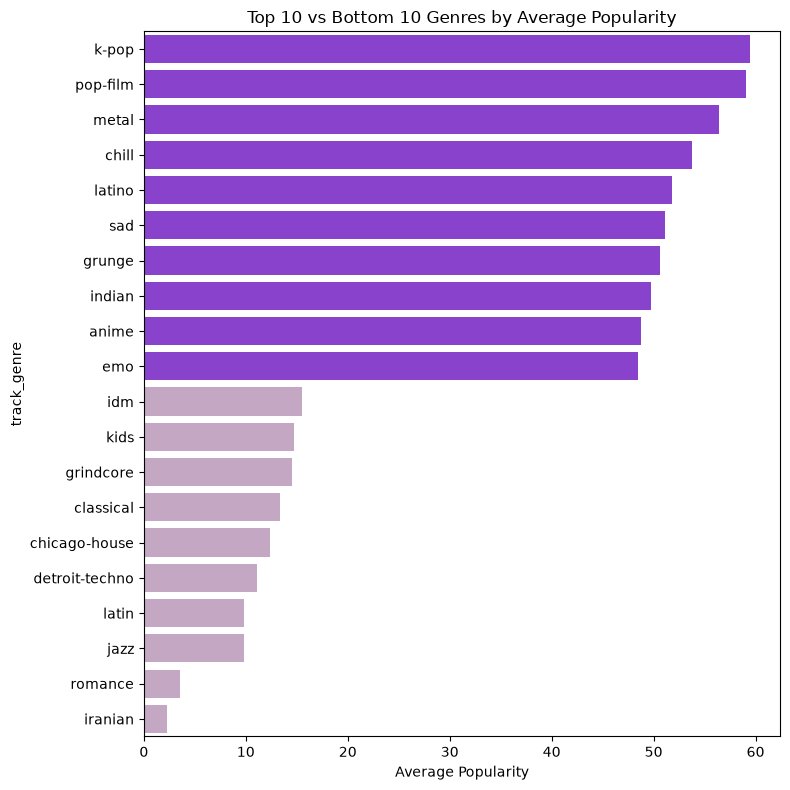

In [107]:
plt.figure(figsize=(8, 8))
colors = ['#8A2BE2'] * 10 + ['#C8A2C8'] * 10
sns.barplot(x=combined.values, y=combined.index, hue=combined.index, palette=colors, legend=False)
plt.xlabel('Average Popularity')
plt.title('Top 10 vs Bottom 10 Genres by Average Popularity')
plt.tight_layout()
plt.savefig('genre_popularity.png', dpi=150)
plt.show()

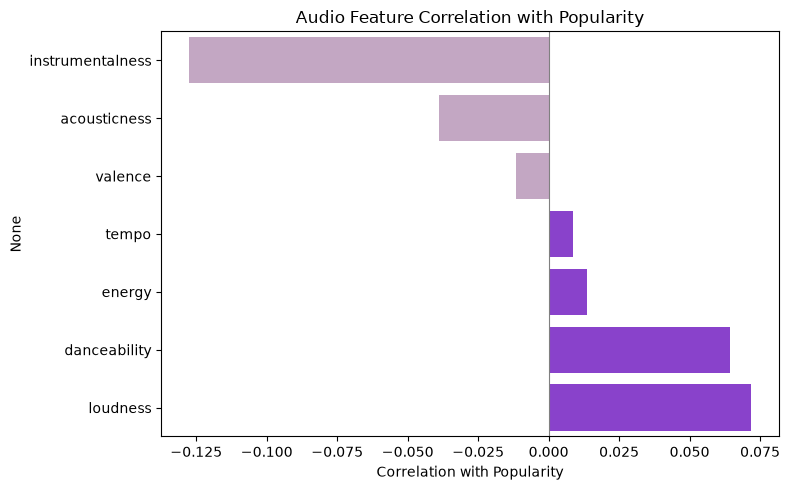

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['#C8A2C8' if v < 0 else '#8A2BE2' for v in corr_values.values]
sns.barplot(x=corr_values.values, y=corr_values.index, hue=corr_values.index, palette=colors, legend=False)
plt.xlabel('Correlation with Popularity')
plt.title('Audio Feature Correlation with Popularity')
plt.axvline(x=0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150)
plt.show()

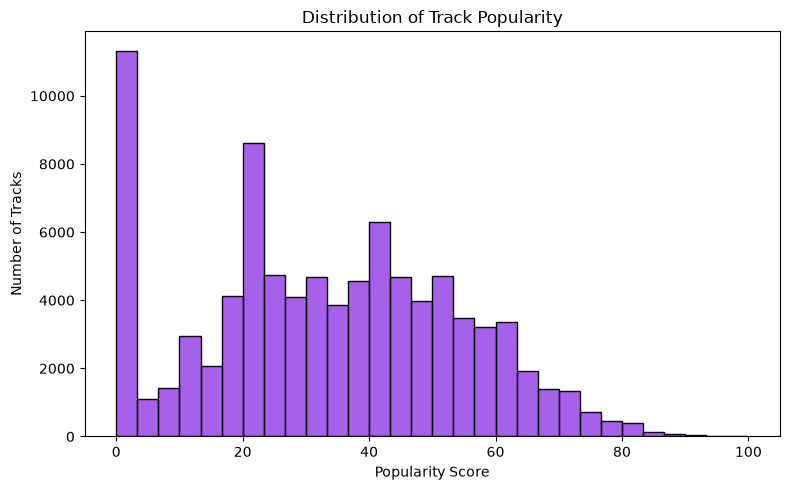

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_unique['popularity'], bins=30, color='#8A2BE2')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Track Popularity')
plt.tight_layout()
plt.savefig('popularity_distribution.png', dpi=150)
plt.show()

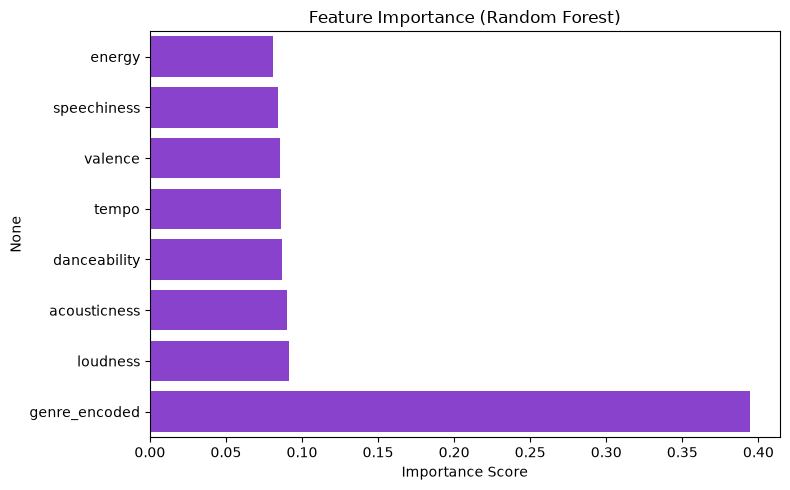

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=model_features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, 
            palette=['#8A2BE2'] * len(importances), legend=False)
plt.xlabel('Importance Score')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 5. Error Analysis

Looking at the model's worst individual predictions to understand *why* it fails, not just how often.

In [ ]:
results = X_test.copy()
results['actual_popularity'] = y_test
results['predicted_popularity'] = rf_predictions
results['error'] = results['actual_popularity'] - results['predicted_popularity']
results['abs_error'] = results['error'].abs()

worst_predictions = results.sort_values('abs_error', ascending=False)

print(worst_predictions[['track_genre', 'actual_popularity', 'predicted_popularity', 'error']].head(15))

             track_genre  actual_popularity  predicted_popularity      error
67500              latin                 95              7.913625  87.086375
20418              dance                 86              0.000000  86.000000
20602              dance                 84              0.891187  83.108813
20026              dance                 86              3.011012  82.988988
67356              latin                 98             17.828083  80.171917
99046  singer-songwriter                 82              2.150170  79.849830
3255         alternative                 84              4.980167  79.019833
15017              chill                 76              0.151358  75.848642
68492             latino                  0             75.300000 -75.300000
2312            alt-rock                 80              4.758690  75.241310
67353              latin                 82              6.826768  75.173232
88903             reggae                 76              0.970602  75.029398

In [ ]:
worst_with_names = df_unique.loc[worst_predictions.head(15).index, ['track_name', 'artists']]
print(worst_with_names)

                  track_name                               artists
67500          Ojitos Lindos               Bad Bunny;Bomba Estéreo
20418              The Motto                        Tiësto;Ava Max
20602    Leave The Door Open  Bruno Mars;Anderson .Paak;Silk Sonic
20026             The Nights                                Avicii
67356             La Bachata                         Manuel Turizo
99046      Victoria’s Secret                                   Jax
3255          Feel Good Inc.                              Gorillaz
15017            At My Worst                           Pink Sweat$
68492               Perreito                        Mariah Angeliq
2312   Bitter Sweet Symphony                             The Verve
67353               Gasolina                          Daddy Yankee
88903                BICHOTA                               KAROL G
91010                Thunder                       Imagine Dragons
15005            At My Worst                           Pink Sw

**Finding:** the model's worst errors were severe underestimates of cross-genre hits (e.g. "Gasolina," "BICHOTA," "Thunder") — songs tagged under a lower-popularity genre during arbitrary deduplication (`keep='first'`), which dragged their genre-based prediction down despite being genuine mainstream hits.

**Takeaway:** this is a methodology limitation, not a modeling failure — future work could encode genre using each song's highest-popularity tag instead of an arbitrary one.

## 6. Saving the Model

Saving the trained model and genre mapping so they can be loaded independently by the deployment API (`app.py`), without retraining.

In [ ]:
import joblib

In [ ]:
joblib.dump(rf_model, 'popularity_model.pkl')

joblib.dump(genre_means, 'genre_means.pkl')

print("Model and genre mapping saved!")

Model and genre mapping saved!
